# Notebook 02: Exploratory Data Analysis on Smoothed Technical Features

This notebook covers **Chapter 3 (Exploratory Data Analysis)** based on the output of Notebook 01.

Focus areas:
1. Statistical summary using full dataset structure (`pandas.info()` + descriptive tables).
2. Correlation analysis with next-day return label.
3. Trend and pattern discovery with rich visuals (histograms, box plots, time-series, scatter plots).

The notebook prioritizes interpretability and report-ready explanations.


In [55]:
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 200)

In [56]:
CONFIG_PATH = Path("../data/processed/modeling_config.json")

import json
cfg = json.loads(CONFIG_PATH.read_text(encoding="utf-8"))

data_csv = Path(cfg["data_csv"])
df = pd.read_csv(data_csv, index_col=0, parse_dates=True)

df = df.sort_index()
feature_cols = cfg["train_feature_cols"]
target_col = cfg["target_col"]

print("Loaded target:", target_col)
print("Loaded training features:", feature_cols)
df.head()

Loaded target: target_close_1d
Loaded training features: ['rsi_14', 'macd_hist_12_26_9', 'bb_bandwidth_20_2', 'adx_14', 'obv', 'adj_close_smooth', 'ema_20', 'atr_14']


,close,Adj Close,adj_close_smooth,target_ret_1d_pct,rsi_14,macd_hist_12_26_9,adx_14,atr_14,obv,sma_10,ema_20,bb_bandwidth_20_2,target_close_1d
Date,,,,,,,,,,,,,
2021-05-28,124.610001,121.575737,122.914878,-0.264829,10.999762,0.292012,60.467386,4.259411,-1.091632e+09,123.376986,125.065324,6.769305,121.253769
2021-06-01,124.279999,121.253769,122.582656,0.627604,10.208686,0.273613,61.439864,4.241367,-1.166708e+09,123.235283,124.828880,6.054030,122.014763
2021-06-02,125.059998,122.014763,122.469077,-1.215384,9.945350,0.262068,62.446581,4.224318,-1.238624e+09,123.126017,124.604137,5.490126,120.531815
2021-06-03,123.540001,120.531815,122.081625,1.902205,9.084466,0.237350,63.543032,4.191809,-1.311403e+09,123.016165,124.363897,5.070044,122.824577
2021-06-04,125.889999,122.824577,122.230215,0.007951,12.222553,0.239339,64.620172,4.188179,-1.238146e+09,122.900575,124.160690,4.522970,122.834343


## 1) Statistical Summary (Full Dataset Structure)

The assignment guideline asks for statistical summarization and clear dataset inspection. We therefore include:
- `df.info()` to show data types, non-null counts, and memory usage.
- Missing-value table.
- Descriptive statistics for all numeric fields.


In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1222 entries, 2021-05-28 to 2026-04-10
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   close              1222 non-null   float64
 1   Adj Close          1222 non-null   float64
 2   adj_close_smooth   1222 non-null   float64
 3   target_ret_1d_pct  1222 non-null   float64
 4   rsi_14             1222 non-null   float64
 5   macd_hist_12_26_9  1222 non-null   float64
 6   adx_14             1222 non-null   float64
 7   atr_14             1222 non-null   float64
 8   obv                1222 non-null   float64
 9   sma_10             1222 non-null   float64
 10  ema_20             1222 non-null   float64
 11  bb_bandwidth_20_2  1222 non-null   float64
 12  target_close_1d    1222 non-null   float64
dtypes: float64(13)
memory usage: 133.7 KB


### Insight Justification: Dataset Structure

`df.info()` verifies data types, non-null coverage, and memory footprint.
This is important because reliable preprocessing and valid EDA conclusions depend on clean, numerically consistent inputs.


In [58]:
desc_tbl = df.describe().T
desc_tbl

,count,mean,std,min,25%,50%,75%,max
close,1222.0,1.902425e+02,4.024319e+01,1.235400e+02,1.557575e+02,1.806400e+02,2.237275e+02,2.861900e+02
Adj Close,1222.0,1.883120e+02,4.110237e+01,1.205318e+02,1.530986e+02,1.781706e+02,2.223939e+02,2.859225e+02
adj_close_smooth,1222.0,1.878743e+02,4.080945e+01,1.220816e+02,1.526520e+02,1.777357e+02,2.219088e+02,2.792980e+02
target_ret_1d_pct,1222.0,7.641414e-02,1.735472e+00,-9.245610e+00,-7.588712e-01,1.114573e-01,9.508204e-01,1.532884e+01
rsi_14,1222.0,5.773762e+01,2.734461e+01,6.750573e+00,3.382062e+01,5.857603e+01,8.465428e+01,9.878123e+01
macd_hist_12_26_9,1222.0,1.001871e-04,8.087405e-01,-2.457550e+00,-5.020299e-01,6.073561e-02,5.419744e-01,2.228849e+00
adx_14,1222.0,5.142142e+01,1.830528e+01,1.782681e+01,3.714802e+01,4.974261e+01,6.450789e+01,9.424040e+01
atr_14,1222.0,4.572019e+00,9.284368e-01,2.883482e+00,3.907160e+00,4.487040e+00,5.101489e+00,9.030788e+00
obv,1222.0,5.246741e+09,3.160023e+09,-1.311403e+09,2.373070e+09,5.495647e+09,7.798653e+09,1.130938e+10
sma_10,1222.0,1.873905e+02,4.071843e+01,1.226252e+02,1.517794e+02,1.773610e+02,2.214959e+02,2.784994e+02


### Insight Justification: Descriptive Statistics

Descriptive statistics summarize center, spread, and extremes for each variable.
These summaries help identify volatility intensity, outlier risk, and scale differences that affect model behavior and interpretation quality.


## 2) Target Distribution Analysis

A good regression study should inspect the label distribution for:
- central tendency,
- volatility,
- skewness/outliers.

This supports downstream model/metric interpretation.


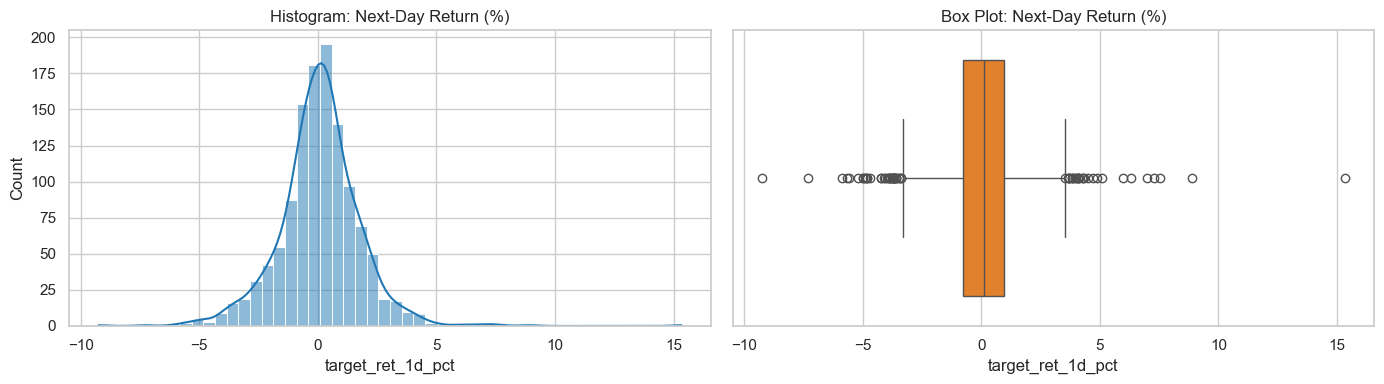

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df["target_ret_1d_pct"], bins=50, kde=True, ax=axes[0], color="#1f77b4")
axes[0].set_title("Histogram: Next-Day Return (%)")
axes[0].set_xlabel("target_ret_1d_pct")

sns.boxplot(x=df["target_ret_1d_pct"], ax=axes[1], color="#ff7f0e")
axes[1].set_title("Box Plot: Next-Day Return (%)")
axes[1].set_xlabel("target_ret_1d_pct")

plt.tight_layout()
plt.show()

### Insight Justification: Target Distribution

Histogram and box plot of `target_ret_1d_pct` show whether returns are symmetric, heavy-tailed, or outlier-prone.
This directly supports discussion on forecast difficulty and the suitability/limitations of linear models.


## 3) Feature Distribution Analysis (Histogram + Box Plot)

Each selected feature is visualized using:
- histogram (shape/distribution), and
- box plot (spread/outliers).

This helps assess scaling, heavy tails, and regime behavior before modeling.


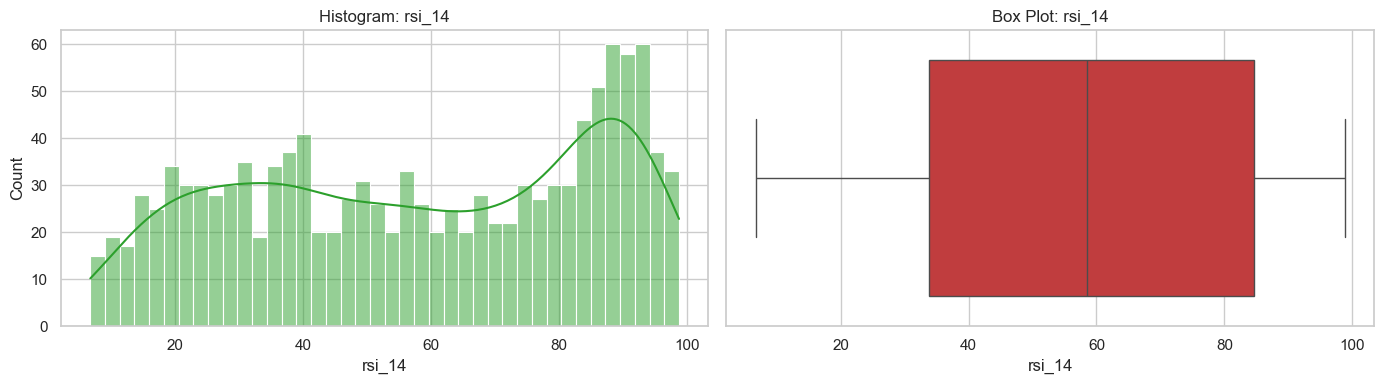

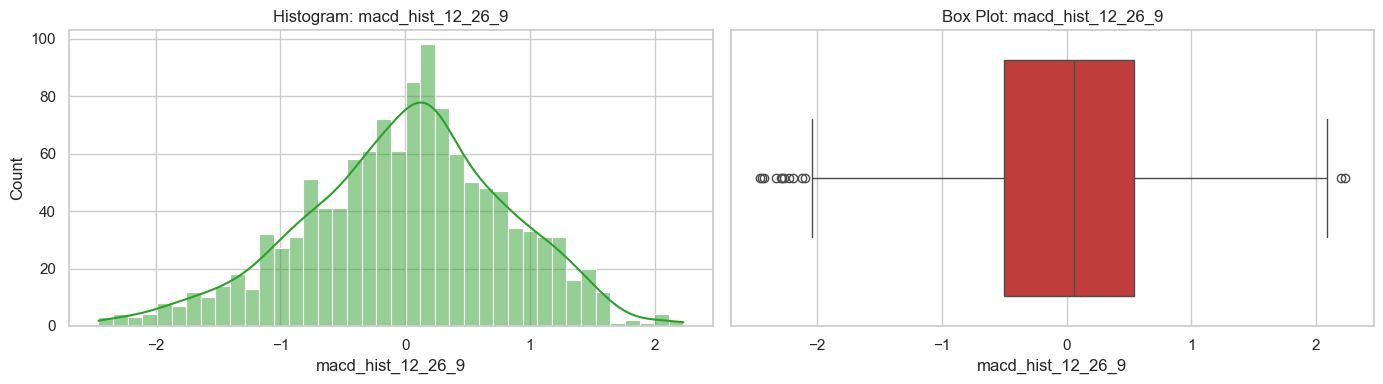

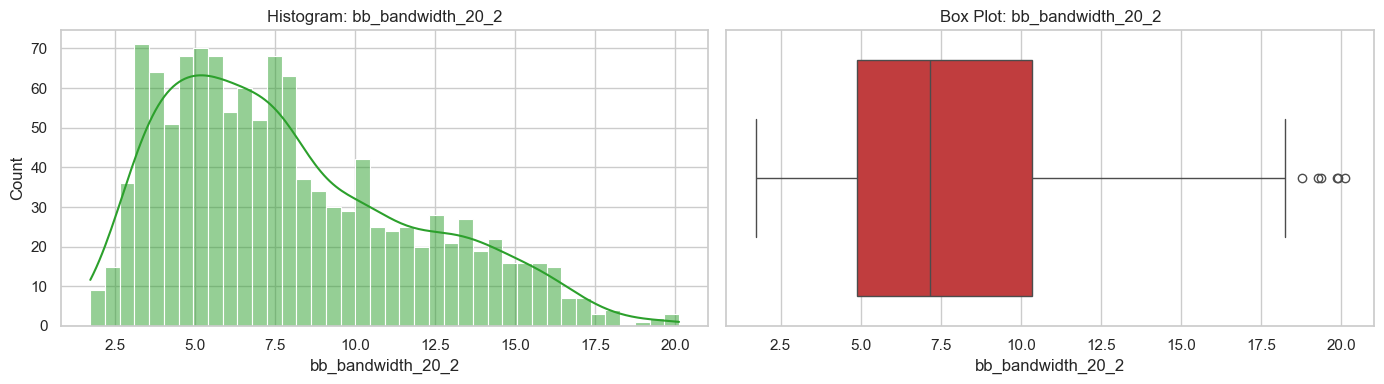

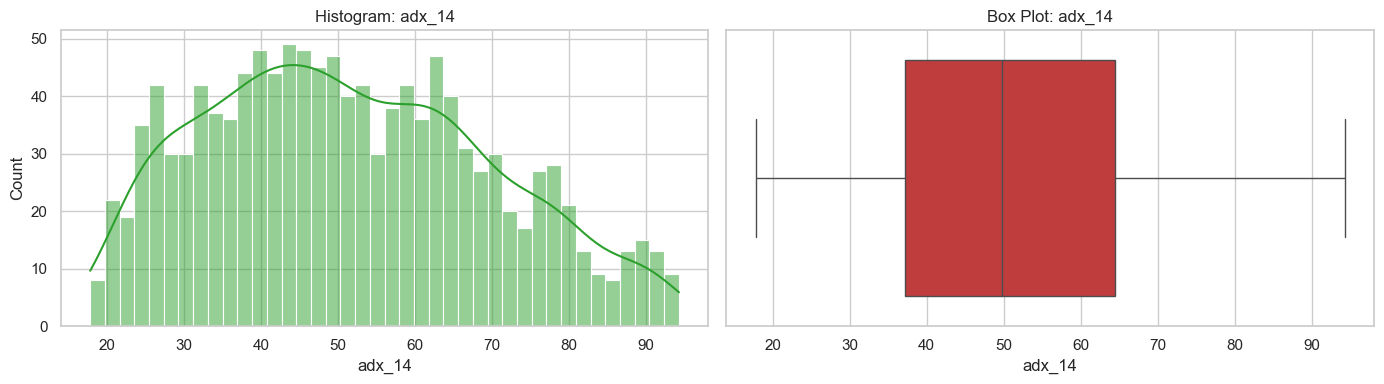

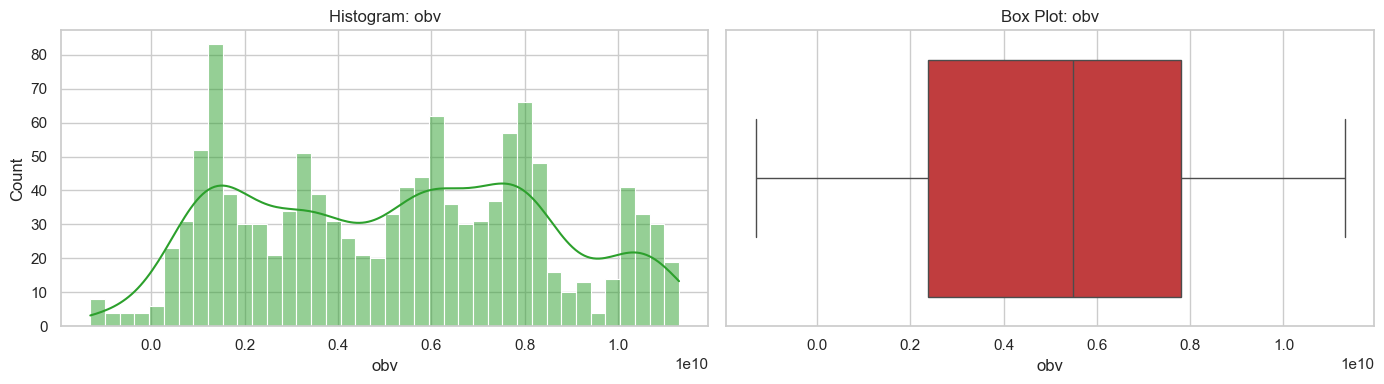

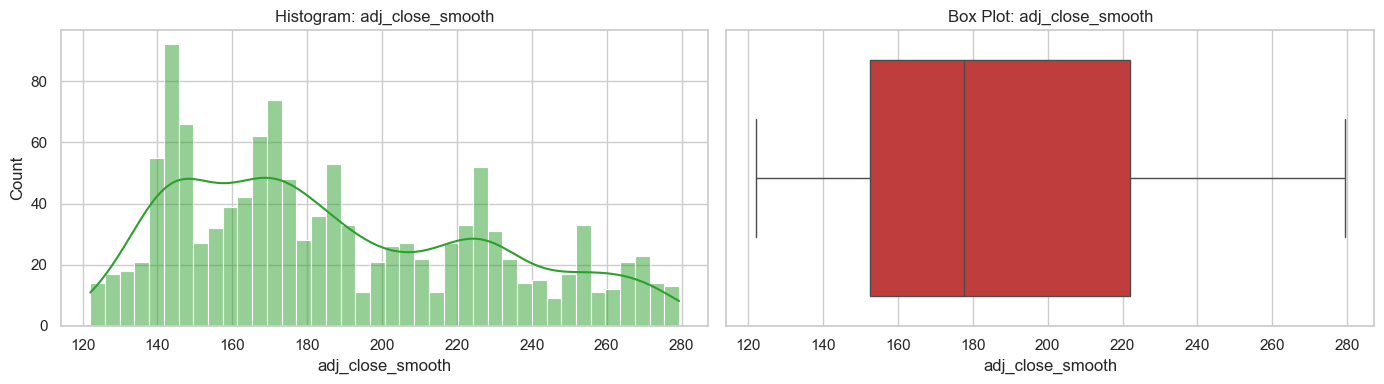

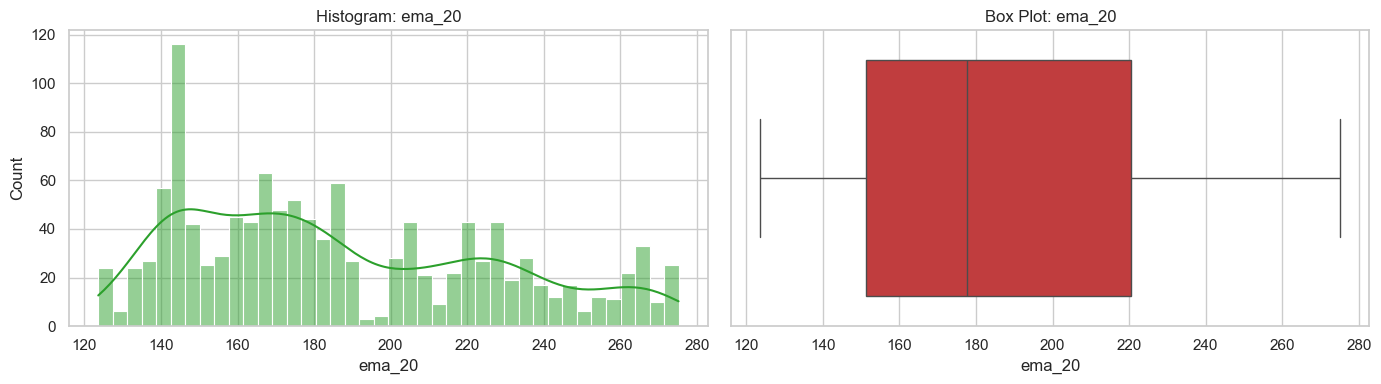

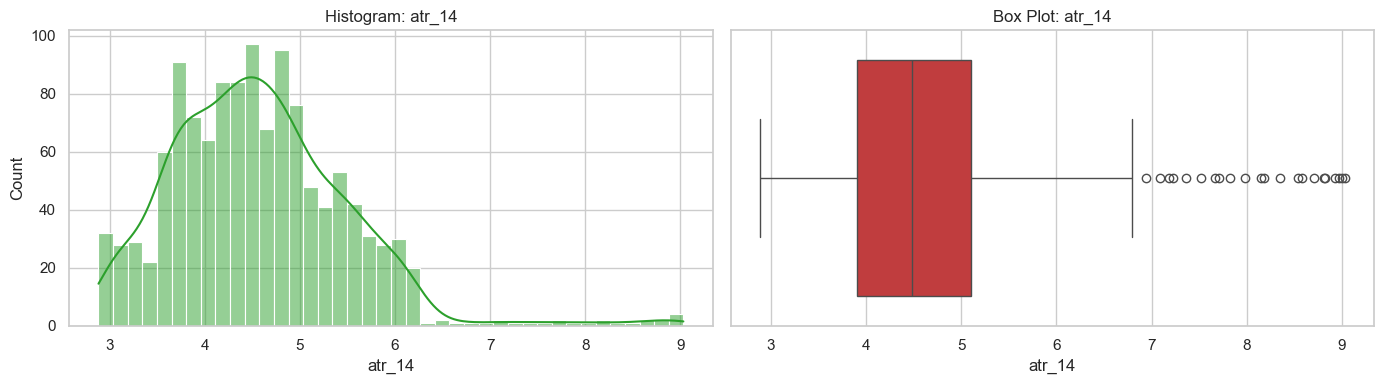

In [60]:
for col in feature_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    sns.histplot(df[col], bins=40, kde=True, ax=axes[0], color="#2ca02c")
    axes[0].set_title(f"Histogram: {col}")
    axes[0].set_xlabel(col)

    sns.boxplot(x=df[col], ax=axes[1], color="#d62728")
    axes[1].set_title(f"Box Plot: {col}")
    axes[1].set_xlabel(col)

    plt.tight_layout()
    plt.show()

### Insight Justification: Feature Distributions

Feature-wise histograms and box plots reveal each indicator's shape, spread, and extreme behavior.
This supports interpretation of market regimes and highlights whether transformation/scaling may be needed in later modeling chapters.


## 4) Correlation Analysis with Target

We compute Pearson correlations between each feature and `target_ret_1d_pct`.

A feature-feature heatmap is also included to inspect remaining multicollinearity.


In [61]:
pearson = df[feature_cols + [target_col]].corr(method="pearson")
pearson[target_col].drop(target_col).sort_values(ascending=False)

adj_close_smooth     0.991835
ema_20               0.977030
obv                  0.960799
rsi_14               0.179844
atr_14               0.115369
macd_hist_12_26_9   -0.030267
adx_14              -0.066802
bb_bandwidth_20_2   -0.111885
Name: target_close_1d, dtype: float64

### Insight Justification: Feature-Target Correlation

Pearson and Spearman values quantify linear and monotonic relationships with the next-day return label.
Even modest correlations are informative in finance, where signal-to-noise is usually low.


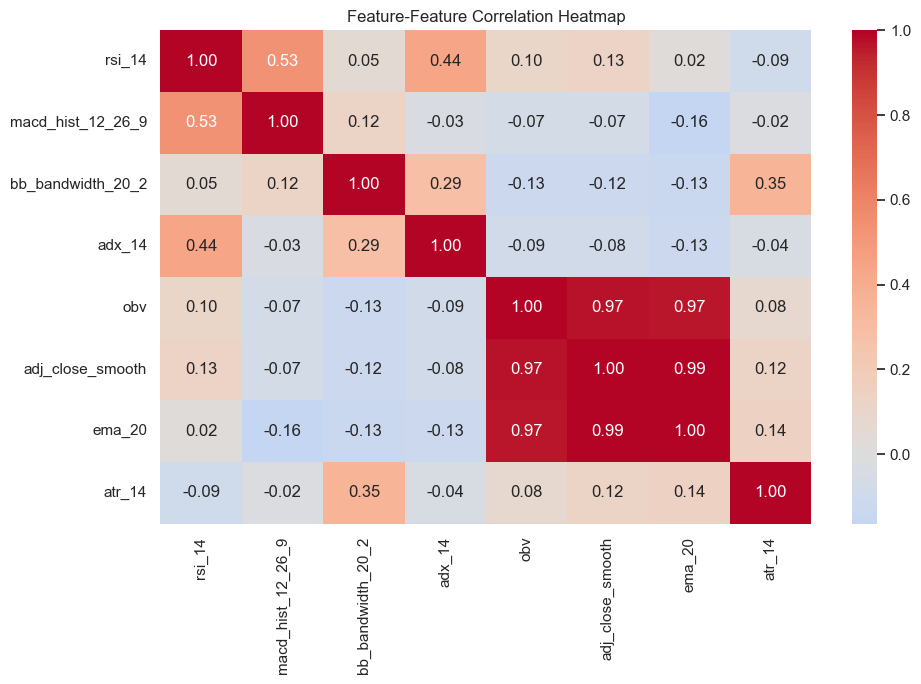

In [62]:
plt.figure(figsize=(10, 7))
sns.heatmap(df[feature_cols].corr(), cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Feature-Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

### Insight Justification: Multicollinearity Check

The heatmap is used to identify redundant indicator pairs.
This helps keep later regression models stable and interpretable by avoiding highly overlapping predictors.


## 5) Trend and Pattern Discovery

Visual trend analysis improves the quality of interpretation in the report. We examine:
- Smoothed vs actual adjusted close over time.
- Feature regime behavior (e.g., ADX trend-strength regimes).
- Scatter relationships against target to evaluate linear suitability.


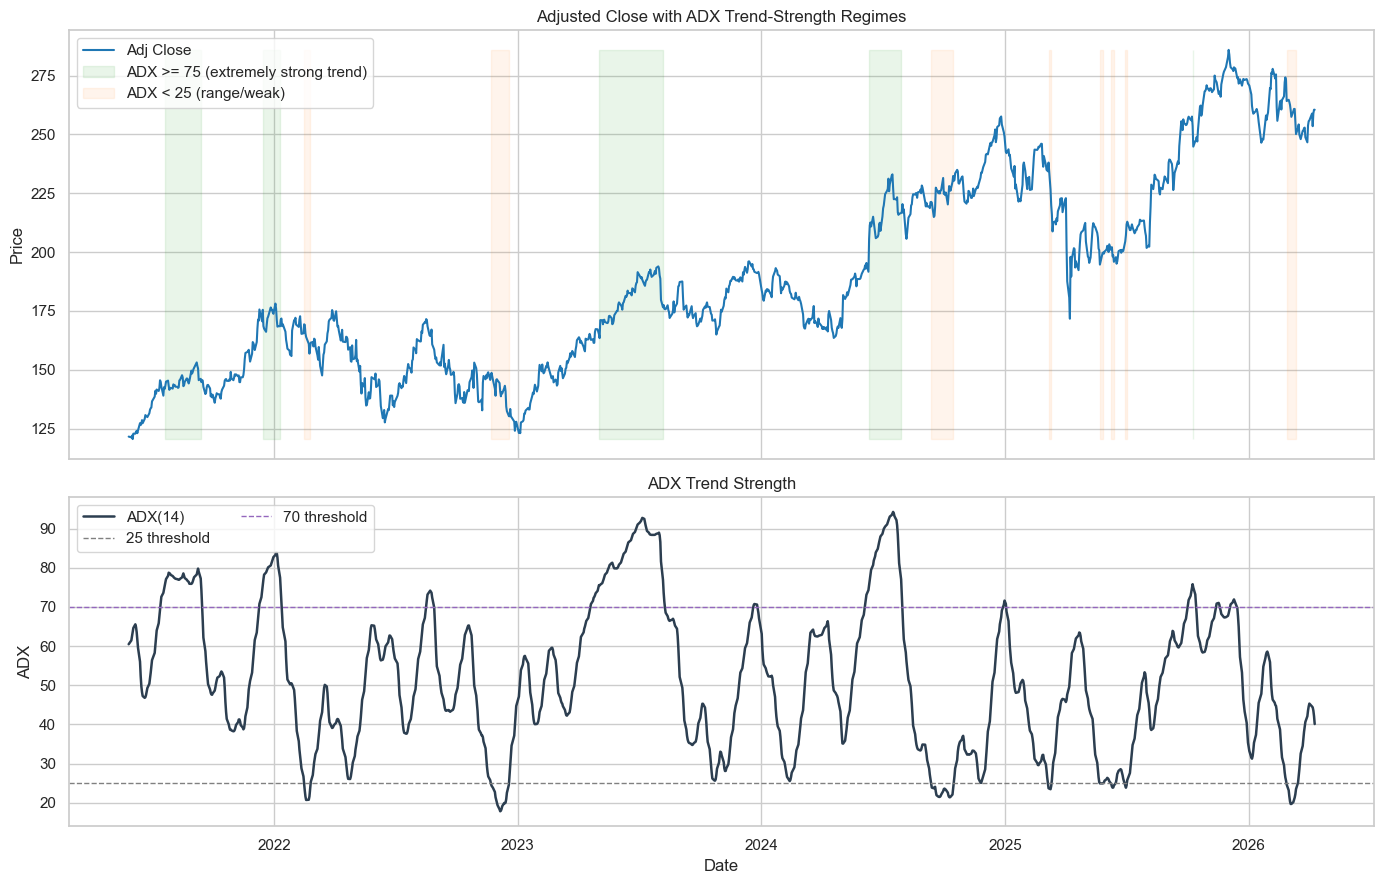

,observations,mean_return_pct,median_return_pct,return_std_pct
adx_regime,,,,
<25 weak,75,-0.2868,-0.2178,1.7278
25-50 strong,541,-0.0220,0.0596,1.7403
50-75 very strong,450,0.2589,0.1851,1.8307
>75 extremely strong,156,0.0658,0.1190,1.3589


In [63]:
# ADX visualization (Investopedia-style strength interpretation)
# ADX is non-directional: it measures trend strength, not up/down direction.
# Common interpretation: <20 weak/range, >25 stronger trend, >50 very strong trend.

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True, gridspec_kw={"height_ratios": [1.3, 1]})

# Panel 1: Price with ADX regime shading
axes[0].plot(df.index, df["Adj Close"], color="#1f77b4", linewidth=1.5, label="Adj Close")

strong = df["adx_14"] >= 75
weak = df["adx_14"] < 25

axes[0].fill_between(df.index, df["Adj Close"].min(), df["Adj Close"].max(), where=strong, color="#2ca02c", alpha=0.10, label="ADX >= 75 (extremely strong trend)")
axes[0].fill_between(df.index, df["Adj Close"].min(), df["Adj Close"].max(), where=weak, color="#ff7f0e", alpha=0.08, label="ADX < 25 (range/weak)")
axes[0].set_title("Adjusted Close with ADX Trend-Strength Regimes")
axes[0].set_ylabel("Price")
axes[0].legend(loc="upper left")

# Panel 2: ADX with thresholds
axes[1].plot(df.index, df["adx_14"], color="#2c3e50", linewidth=1.8, label="ADX(14)")
axes[1].axhline(25, linestyle="--", color="gray", linewidth=1, label="25 threshold")
axes[1].axhline(70, linestyle="--", color="#9467bd", linewidth=1, label="70 threshold")
axes[1].set_title("ADX Trend Strength")
axes[1].set_ylabel("ADX")
axes[1].set_xlabel("Date")
axes[1].legend(loc="upper left", ncol=2)

plt.tight_layout()
plt.show()

# Report-friendly ADX regime summary table
regime = pd.cut(df["adx_14"], bins=[-np.inf, 25, 50, 75, np.inf], labels=["<25 weak", "25-50 strong", "50-75 very strong", ">75 extremely strong"])
regime_summary = (
    df.assign(adx_regime=regime)
      .groupby("adx_regime", observed=False)
      .agg(
          observations=("target_ret_1d_pct", "size"),
          mean_return_pct=("target_ret_1d_pct", "mean"),
          median_return_pct=("target_ret_1d_pct", "median"),
          return_std_pct=("target_ret_1d_pct", "std"),
      )
      .round(4)
)
regime_summary

### Insight Justification: ADX Strength + Direction

Following Investopedia guidance, ADX is used as a **trend-strength** gauge (non-directional), while `+DI` and `-DI` provide directional context.
- `ADX > 25` typically indicates a stronger trend regime.
- `+DI > -DI` suggests upward directional dominance; the reverse suggests downward dominance.

The accompanying regime summary table translates indicator behavior into report-ready return statistics by ADX strength bucket.


## 6) RSI and MACD Event Highlight Analysis

This section visualizes technical indicator states directly against price behavior for clearer trend interpretation.


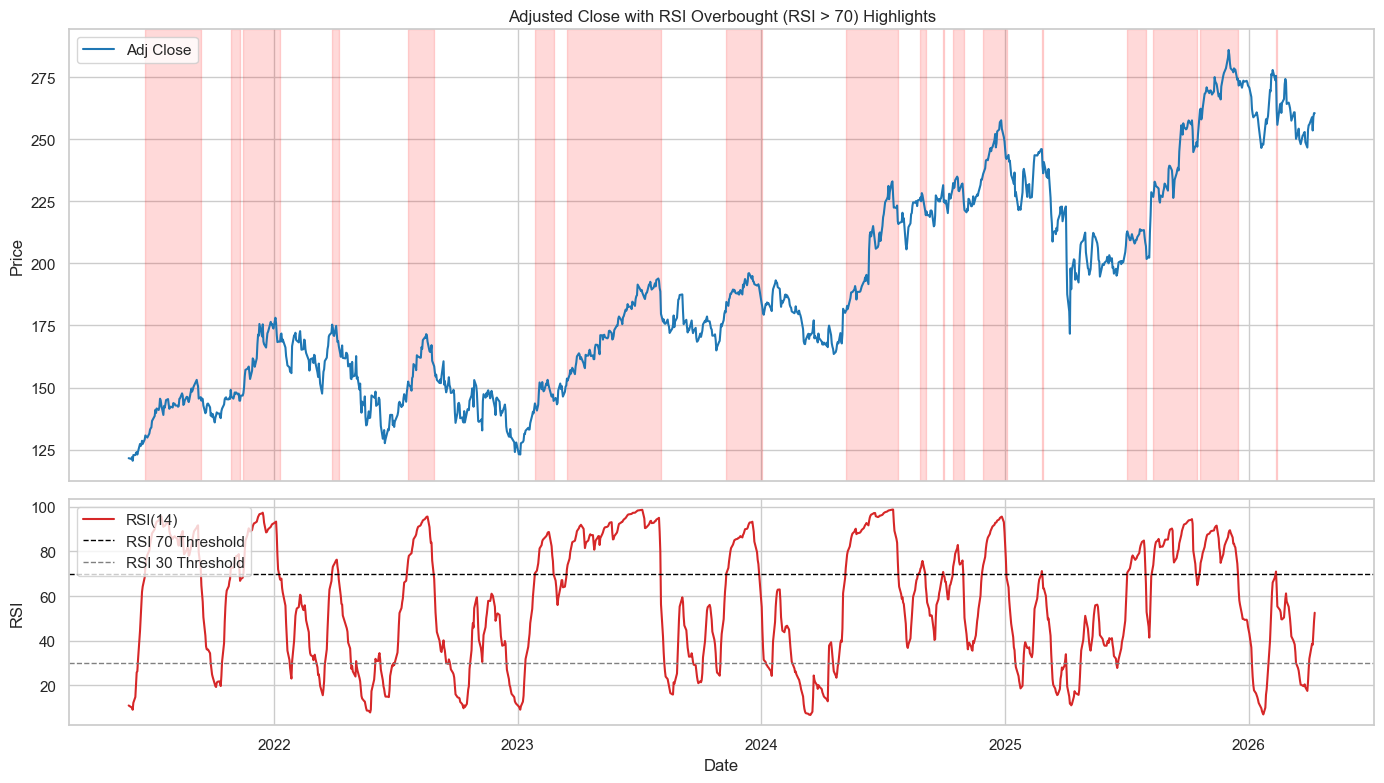

In [64]:
# RSI vs price with overbought highlight (RSI > 70)
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True, gridspec_kw={"height_ratios": [2, 1]})

axes[0].plot(df.index, df["Adj Close"], color="#1f77b4", label="Adj Close")
axes[0].set_title("Adjusted Close with RSI Overbought (RSI > 70) Highlights")
axes[0].set_ylabel("Price")

rsi_overbought = df["rsi_14"] > 70
if rsi_overbought.any():
    start = None
    for idx, flag in rsi_overbought.items():
        if flag and start is None:
            start = idx
        elif not flag and start is not None:
            axes[0].axvspan(start, idx, color="red", alpha=0.15)
            start = None
    if start is not None:
        axes[0].axvspan(start, df.index[-1], color="red", alpha=0.15)

axes[1].plot(df.index, df["rsi_14"], color="#d62728", label="RSI(14)")
axes[1].axhline(70, linestyle="--", color="black", linewidth=1, label="RSI 70 Threshold")
axes[1].axhline(30, linestyle="--", color="gray", linewidth=1, label="RSI 30 Threshold")
axes[1].set_ylabel("RSI")
axes[1].set_xlabel("Date")

axes[0].legend(loc="upper left")
axes[1].legend(loc="upper left")
plt.tight_layout()
plt.show()

### Insight Justification: RSI Overbought Windows

RSI-over-70 windows can indicate stretched momentum conditions.
Overlaying these windows on price helps discuss whether local pullbacks or continued momentum were more common in this dataset.


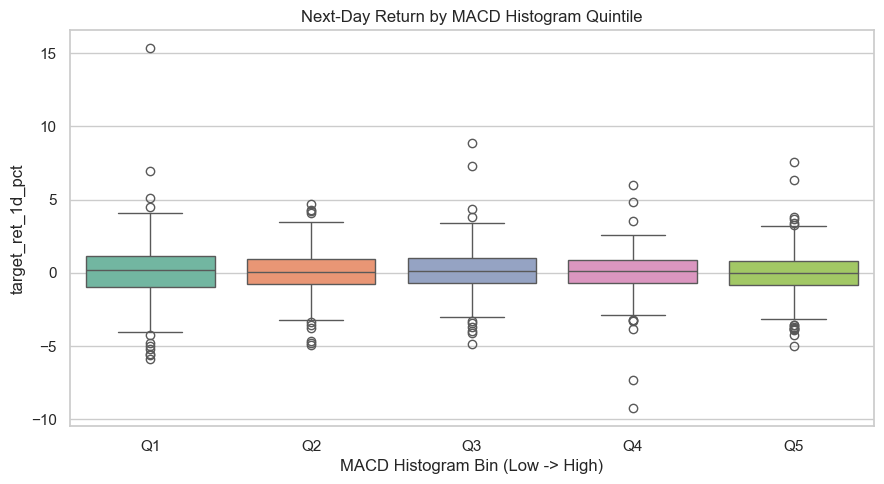

In [65]:
# MACD relationship with next-day return (quintile boxplot only)
macd_bins = pd.qcut(df["macd_hist_12_26_9"], q=5, labels=["Q1", "Q2", "Q3", "Q4", "Q5"], duplicates="drop")

plot_df = df[["target_ret_1d_pct"]].copy()
plot_df["macd_bin"] = macd_bins

plt.figure(figsize=(9, 5))
sns.boxplot(data=plot_df, x="macd_bin", y="target_ret_1d_pct", hue="macd_bin", palette="Set2", legend=False)
plt.title("Next-Day Return by MACD Histogram Quintile")
plt.xlabel("MACD Histogram Bin (Low -> High)")
plt.ylabel("target_ret_1d_pct")
plt.tight_layout()
plt.show()

### Insight Justification: MACD Quintile Comparison

The quintile boxplot is easier to interpret than a dense scatter in noisy financial data.
It shows how next-day return distribution shifts from low to high MACD states, including median movement, spread, and outlier behavior in each momentum regime.

`Q1` to `Q5` are **quintile bins** of your `MACD histogram` values:

- `Q1` = lowest 20% of MACD histogram values (most negative/weakest momentum)
- `Q2` = next 20%
- `Q3` = middle 20%
- `Q4` = next 20%
- `Q5` = highest 20% (most positive/strongest momentum)

So the boxplot compares next-day return distributions across low-to-high MACD momentum regimes.


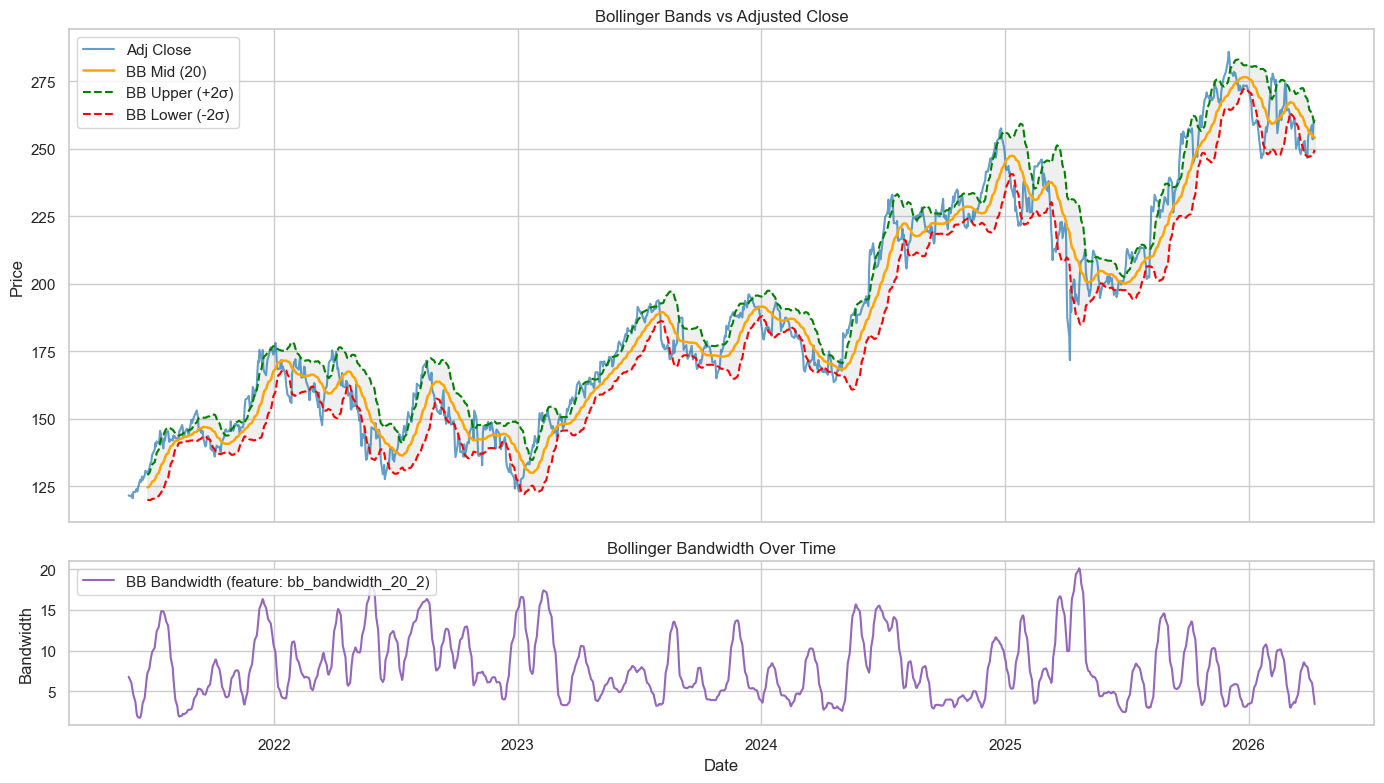

In [66]:
# Bollinger Bands (20,2) against adjusted close + Bandwidth
rolling_mid = df["adj_close_smooth"].rolling(window=20).mean()
rolling_std = df["adj_close_smooth"].rolling(window=20).std()
bb_upper = rolling_mid + 2 * rolling_std
bb_lower = rolling_mid - 2 * rolling_std
bb_width = bb_upper - bb_lower

fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]},
)

# Price + bands
ax = axes[0]
ax.plot(df.index, df["Adj Close"], label="Adj Close", color="#1f77b4", alpha=0.7)
ax.plot(df.index, rolling_mid, label="BB Mid (20)", color="orange", linewidth=1.8)
ax.plot(df.index, bb_upper, label="BB Upper (+2σ)", color="green", linestyle="--")
ax.plot(df.index, bb_lower, label="BB Lower (-2σ)", color="red", linestyle="--")
ax.fill_between(df.index, bb_lower, bb_upper, color="gray", alpha=0.12)
ax.set_title("Bollinger Bands vs Adjusted Close")
ax.set_ylabel("Price")
ax.legend(loc="upper left")

# Bandwidth
ax2 = axes[1]
if "bb_bandwidth_20_2" in df.columns:
    bandwidth = df["bb_bandwidth_20_2"]
    ax2.plot(df.index, bandwidth, label="BB Bandwidth (feature: bb_bandwidth_20_2)", color="#9467bd")
else:
    bandwidth = (bb_width / rolling_mid) * 100
    ax2.plot(df.index, bandwidth, label="BB Bandwidth (%): (Upper-Lower)/Mid * 100", color="#9467bd")

ax2.set_title("Bollinger Bandwidth Over Time")
ax2.set_xlabel("Date")
ax2.set_ylabel("Bandwidth")
ax2.legend(loc="upper left")

plt.tight_layout()
plt.show()

### Insight Justification: Bollinger Band Context

**What they are:** Bollinger Bands are a moving-average envelope built from a 20-period rolling mean (mid band) and a volatility term (rolling standard deviation).

**Construction (20,2):**
- Mid band: 20-day rolling mean of price (here `adj_close_smooth`).
- Upper band: Mid + 2σ (2 standard deviations).
- Lower band: Mid - 2σ.

**Bandwidth / width:** The band *width* is the distance between upper and lower bands (`Upper - Lower`). In many implementations, *bandwidth* is this width normalized by the mid band (often `(Upper - Lower) / Mid`, sometimes expressed as a %).

**How to interpret it:**
- Higher bandwidth typically indicates higher volatility.
- Very low bandwidth is often called a "squeeze" (volatility contraction), which can precede volatility expansion.
- Bandwidth is primarily a volatility signal; it does not by itself predict direction.

In this project, the second plot visualizes the feature `bb_bandwidth_20_2` (used later in modeling), so you can relate the numeric feature directly to the band expansion/contraction seen in the top chart.


## 7) EDA Interpretation Notes for Report Writing

Use this section to summarize Chapter 3 insights in your report:

1. Statistical profile:
   - Describe central tendency and dispersion of `target_ret_1d_pct`.
   - Mention any visible skewness and outliers.

2. Feature behavior:
   - Highlight which indicators are stable vs highly volatile.
   - Note any non-Gaussian feature distributions.

3. Correlation findings:
   - Report strongest positive/negative feature-target relationships.
   - Discuss whether correlations are weak/moderate/strong and implications for linear regression.

4. Regime insights:
   - Explain how target distribution differs between trending and ranging periods (ADX regimes).

5. Model implication:
   - If relationships appear weakly linear or regime-dependent, note this as motivation for comparing additional models in later chapters.
